<a href="https://colab.research.google.com/github/Elsacred02/assignment_3_advanced_machine_learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

L'obiettivo è stato quello di modificare la CNN presentata a lezione cercando di massimizzare l'accuratezza del modello, che non deve superare i 7000 parametri addestrabili.

## Dipendenze ed operazioni preliminari

In [1]:
# Import dependencies
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# set seed
keras.utils.set_random_seed(42)

In [2]:
# load the data and divide it into train/test split
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


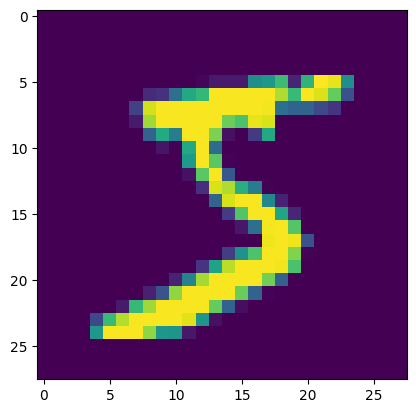

Label: 5


In [3]:
# Show the first element
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
print(f"Label: {y_train[0]}")



In [4]:
# Scale images into the [0 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make images with size (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [5]:
# convert class array into one-hot representation
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# we have seen this class is 5
print(y_train.shape)
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Creazione del modello

Per risolvere l'assignment è stata utilizzata l'idea alla base delle architetture VGG. La rete creata ha:


*   Un **livello di input**, la cui dimensione è pari a quella delle immagini che stiamo prendendo in considerazione.
*   Due **livelli convoluzionali**, ciascuno dei quali è formato da *8* filtri con dimensione *3 x 3*.
*   Un **livello di pooling**, che utilizza la tecnica di scelta del valore massimo all'interno della finestra di dimensione *2 x 2*.
*   Due **livelli convoluzionali**, ciascuno dei quali è formato da *16* filtri di dimesnione *3 x 3*.
*   Un ulteriore **livello di pooling** con la stessa struttura adottata in precedenza.
*   Un **livello di appiattimento**, per ottenere il vettore di feature da fornire in ingresso ad un layer denso per la classificazione.


In questo modo è stato possibile ottenere un modello con meno di 7000 parametri che permettesse di ottenere un'accuratezza elevata nella classificazione (tra il 98.5% circa).

Total params = 6722
= (3 * 3 * 8 + 8) + (3 * 3 * 8 * 8 + 8) + (3 * 3 * 8 * 16 + 16) + (3 * 3 * 16 * 16 + 16) + (256 * 10 + 10) = 80 + 584 + 1168 + 2320 + 2570



In [6]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(8, kernel_size=3, activation="relu"),
      layers.Conv2D(8, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,722 (26.26 KB)

 Trainable params: 6,722 (26.26 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5644 - loss: 1.2375 - val_accuracy: 0.9588 - val_loss: 0.1359
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9288 - loss: 0.2326 - val_accuracy: 0.9750 - val_loss: 0.0861
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9493 - loss: 0.1666 - val_accuracy: 0.9796 - val_loss: 0.0705
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9558 - loss: 0.1389 - val_accuracy: 0.9804 - val_loss: 0.0664
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9634 - loss: 0.1179 - val_accuracy: 0.9826 - val_loss: 0.0595


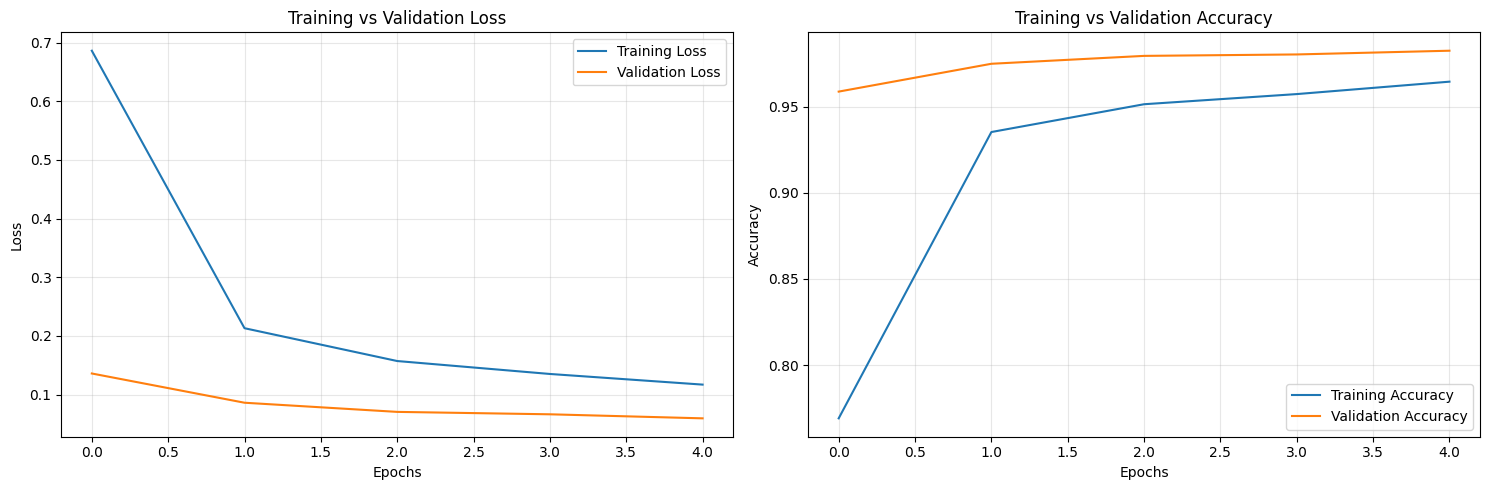

In [8]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.04795648157596588
Test accuracy 0.9850000143051147


# Confronto con modello visto a lezione

In questa sezione viene presentato il modello di CNN visto a lezione; come è possibile notare, a fronte di una diminuzione molto alta del numero di parametri, è stato possibile mantenere l'accuratezza.

In [10]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(32, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(64, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7712 - loss: 0.7856 - val_accuracy: 0.9712 - val_loss: 0.1030
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9609 - loss: 0.1283 - val_accuracy: 0.9797 - val_loss: 0.0745
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9701 - loss: 0.0920 - val_accuracy: 0.9835 - val_loss: 0.0580
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0781 - val_accuracy: 0.9849 - val_loss: 0.0532
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9791 - loss: 0.0653 - val_accuracy: 0.9871 - val_loss: 0.0476


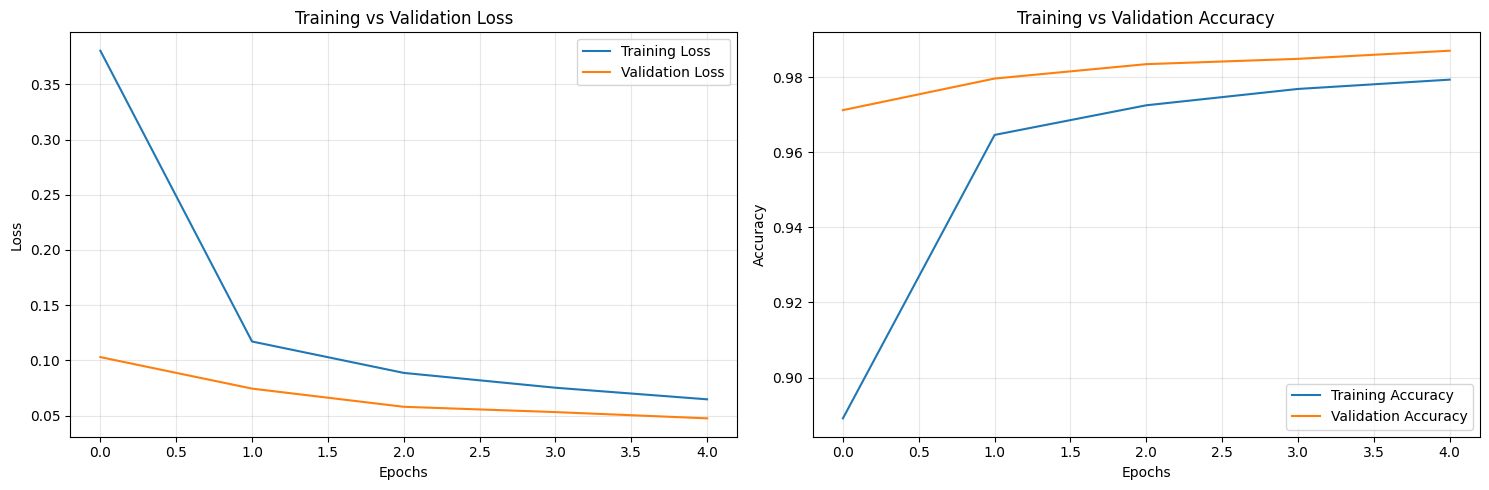

In [12]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.037278782576322556
Test accuracy 0.9876000285148621


# Confronto con un modello più semplice con meno di 7000 parametri

In questa sezione viene presentato un modello di CNN con meno di 7000 paramentri.

In questo caso viene effettuato il pooling dopo ogni convoluzione, questo implica le convoluzioni effettuate nei livelli successivi lavorano su una rappresentazione meno dettagliata; di conseguenza riescono ad estrarre pattern meno complessi portando a risultati peggiori rispetto al modello finale.

In [14]:
# Model/data parameters
num_classes = 10
input_shape = (28,28,1)

model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(16, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax")
    ]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,970 (19.41 KB)

 Trainable params: 4,970 (19.41 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from sklearn import metrics
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3488 - loss: 1.8221 - val_accuracy: 0.8527 - val_loss: 0.6110
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6523 - loss: 0.9893 - val_accuracy: 0.9000 - val_loss: 0.4022
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6992 - loss: 0.8433 - val_accuracy: 0.9165 - val_loss: 0.3382
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7325 - loss: 0.7665 - val_accuracy: 0.9262 - val_loss: 0.2866
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7476 - loss: 0.7114 - val_accuracy: 0.9336 - val_loss: 0.2611


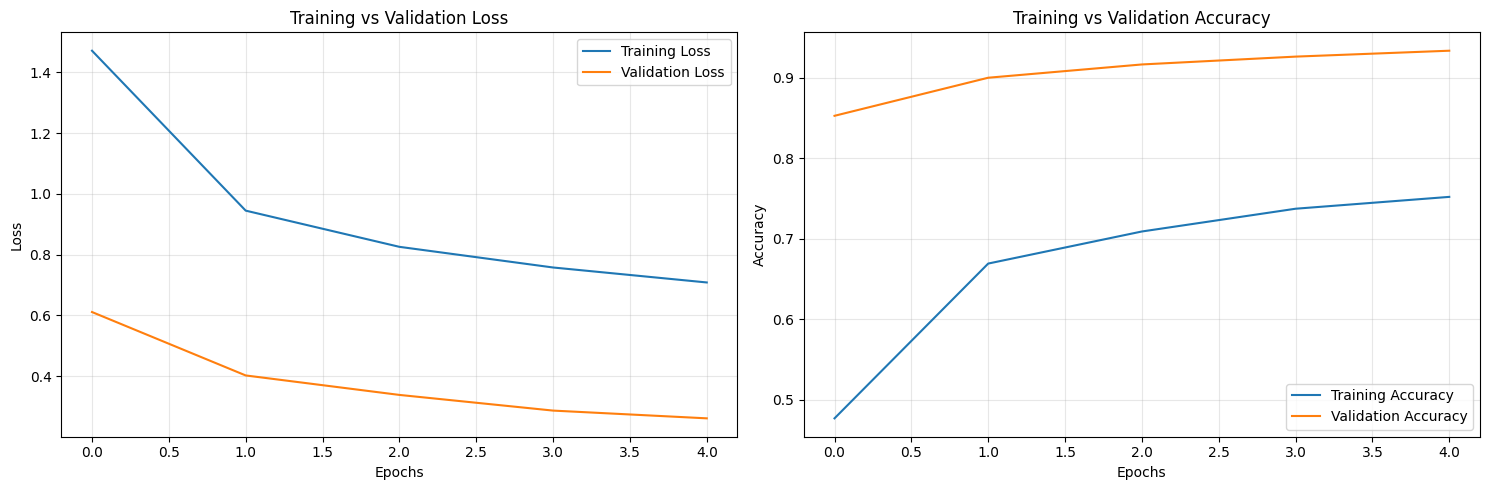

In [16]:
history_dict = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.24801211059093475
Test accuracy 0.9383999705314636
